# Analysis of Air Conditioners (AC) prices of the products in Flipkart


# Using EDA (Exploratory Data Analysis)

### Name :- Yogesh Pawar

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the Data 
df = pd.read_csv(r"D:\Web Scrapping\PROJECT eda\New folder\ac_products_cleaned.csv")
df      

,Product Title,Rating,Reviews,Feature,Original Price,Discount percentage,Discount Price
0,MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...,4.2,"39,287 Ratings & 4,917 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹45,099",51% off,"₹21,990"
1,LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...,4.2,"42,704 Ratings & 4,066 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹78,990",47% off,"₹41,490"
2,MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...,4.2,"39,287 Ratings & 4,917 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹45,099",51% off,"₹21,990"
3,Haier 2025 Model 1 Ton 3 Star Split Dual Inver...,4.2,"1,656 Ratings & 147 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹50,000",50% off,"₹24,990"
4,Voltas 2025 Model 1.5 Ton 3 Star Split Inverte...,4.2,"77,083 Ratings & 6,652 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹57,990",46% off,"₹30,990"
...,...,...,...,...,...,...,...
979,Daikin 2022 Model 2.02 Ton 3 Star Split Invert...,4.2,70 Ratings & 4 Reviews,Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹90,500",22% off,"₹70,450"
980,Godrej 2025 Model 1.5 Ton 3 Star Split Inverte...,4.2,"18,522 Ratings & 1,522 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹45,900",38% off,"₹28,379"
981,Panasonic 2025 Model 1.5 Ton 5 Star Split Inve...,4.2,"20,268 Ratings & 2,167 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹59,300",31% off,"₹40,390"
982,Hitachi 2023 Model 1.5 Ton 3 Star Split Invert...,4.2,"10,223 Ratings & 1,241 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹65,400",48% off,"₹33,985"


In [3]:
# Dataset shape
df.shape

(984, 7)

In [4]:
# Dataset Size
df.size

6888

In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product Title        984 non-null    object 
 1   Rating               984 non-null    float64
 2   Reviews              977 non-null    object 
 3   Feature              984 non-null    object 
 4   Original Price       966 non-null    object 
 5   Discount percentage  965 non-null    object 
 6   Discount Price       984 non-null    object 
dtypes: float64(1), object(6)
memory usage: 53.9+ KB


In [6]:
# Dataset Summary Statistics
df.describe()

,Rating
count,9.840000e+02
mean,4.200000e+00
std,7.553356e-14
min,4.200000e+00
25%,4.200000e+00
50%,4.200000e+00
75%,4.200000e+00
max,4.200000e+00


In [7]:
# Extract Brand (first word of title)
df['Brand'] = df['Product Title'].str.split().str[0]
print(df[['Product Title','Brand']])

                                         Product Title      Brand
0    MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...       MarQ
1    LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...         LG
2    MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...       MarQ
3    Haier 2025 Model 1 Ton 3 Star Split Dual Inver...      Haier
4    Voltas 2025 Model 1.5 Ton 3 Star Split Inverte...     Voltas
..                                                 ...        ...
979  Daikin 2022 Model 2.02 Ton 3 Star Split Invert...     Daikin
980  Godrej 2025 Model 1.5 Ton 3 Star Split Inverte...     Godrej
981  Panasonic 2025 Model 1.5 Ton 5 Star Split Inve...  Panasonic
982  Hitachi 2023 Model 1.5 Ton 3 Star Split Invert...    Hitachi
983  Hitachi 2023 Model 1 Ton 3 Star Split Inverter...    Hitachi

[984 rows x 2 columns]


In [8]:
# Extract the Ton values
df["Ton"] = df['Product Title'].str.extract(r'(\d+\.?\d*)\s*Ton')
print(df[['Product Title','Ton']])

                                         Product Title   Ton
0    MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...     1
1    LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...   1.5
2    MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...     1
3    Haier 2025 Model 1 Ton 3 Star Split Dual Inver...     1
4    Voltas 2025 Model 1.5 Ton 3 Star Split Inverte...   1.5
..                                                 ...   ...
979  Daikin 2022 Model 2.02 Ton 3 Star Split Invert...  2.02
980  Godrej 2025 Model 1.5 Ton 3 Star Split Inverte...   1.5
981  Panasonic 2025 Model 1.5 Ton 5 Star Split Inve...   1.5
982  Hitachi 2023 Model 1.5 Ton 3 Star Split Invert...   1.5
983  Hitachi 2023 Model 1 Ton 3 Star Split Inverter...     1

[984 rows x 2 columns]


In [9]:
# Extract the Star values
df["Star Rating"] = df['Product Title'].str.extract(r'(\d+)\s*Star')
print(df[['Product Title','Star Rating']])

                                         Product Title Star Rating
0    MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...           3
1    LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...           5
2    MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...           3
3    Haier 2025 Model 1 Ton 3 Star Split Dual Inver...           3
4    Voltas 2025 Model 1.5 Ton 3 Star Split Inverte...           3
..                                                 ...         ...
979  Daikin 2022 Model 2.02 Ton 3 Star Split Invert...           3
980  Godrej 2025 Model 1.5 Ton 3 Star Split Inverte...           3
981  Panasonic 2025 Model 1.5 Ton 5 Star Split Inve...           5
982  Hitachi 2023 Model 1.5 Ton 3 Star Split Invert...           3
983  Hitachi 2023 Model 1 Ton 3 Star Split Inverter...           3

[984 rows x 2 columns]


In [10]:
# Check for Duplicate Rows in Dataset
duplicates = df.duplicated()
print(duplicates.sum())

403


In [11]:
# Remove Duplicate Rows 
df = df.drop_duplicates()

In [12]:
# Check for Duplicates After Dropping
duplicates = df.duplicated()
print(duplicates.sum())

0


In [13]:
# Dataset shape after remove Duplicate Rows
df.shape

(581, 10)

In [14]:
# DataFrame
df

,Product Title,Rating,Reviews,Feature,Original Price,Discount percentage,Discount Price,Brand,Ton,Star Rating
0,MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...,4.2,"39,287 Ratings & 4,917 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹45,099",51% off,"₹21,990",MarQ,1,3
1,LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...,4.2,"42,704 Ratings & 4,066 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹78,990",47% off,"₹41,490",LG,1.5,5
3,Haier 2025 Model 1 Ton 3 Star Split Dual Inver...,4.2,"1,656 Ratings & 147 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹50,000",50% off,"₹24,990",Haier,1,3
4,Voltas 2025 Model 1.5 Ton 3 Star Split Inverte...,4.2,"77,083 Ratings & 6,652 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹57,990",46% off,"₹30,990",Voltas,1.5,3
5,Daikin 2025 Model 1.2 Ton 5 Star Split Inverte...,4.2,37 Ratings & 11 Reviews,Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹46,460",22% off,"₹35,990",Daikin,1.2,5
...,...,...,...,...,...,...,...,...,...,...
975,Haier 2023 Model 1.5 Ton 3 Star Split Inverter AC,4.2,"5,460 Ratings & 542 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹80,500",57% off,"₹33,850",Haier,1.5,3
978,Hitachi 2023 Model 1.5 Ton 3 Star Split Invert...,4.2,"10,223 Ratings & 1,241 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹65,200",43% off,"₹36,850",Hitachi,1.5,3
979,Daikin 2022 Model 2.02 Ton 3 Star Split Invert...,4.2,70 Ratings & 4 Reviews,Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹90,500",22% off,"₹70,450",Daikin,2.02,3
982,Hitachi 2023 Model 1.5 Ton 3 Star Split Invert...,4.2,"10,223 Ratings & 1,241 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹65,400",48% off,"₹33,985",Hitachi,1.5,3


In [15]:
# Check Missing Values in Percentage
df.isnull().sum()/len(df)*10

Product Title          0.000000
Rating                 0.000000
Reviews                0.120482
Feature                0.000000
Original Price         0.275387
Discount percentage    0.292599
Discount Price         0.000000
Brand                  0.000000
Ton                    0.086059
Star Rating            0.051635
dtype: float64

In [16]:
# Accessing a Reviews columns
df["Reviews"]

0      39,287 Ratings & 4,917 Reviews
1      42,704 Ratings & 4,066 Reviews
3         1,656 Ratings & 147 Reviews
4      77,083 Ratings & 6,652 Reviews
5             37 Ratings & 11 Reviews
                    ...              
975       5,460 Ratings & 542 Reviews
978    10,223 Ratings & 1,241 Reviews
979            70 Ratings & 4 Reviews
982    10,223 Ratings & 1,241 Reviews
983       2,327 Ratings & 304 Reviews
Name: Reviews, Length: 581, dtype: object

In [17]:
# check Data Types of Each columns
df.dtypes

Product Title           object
Rating                 float64
Reviews                 object
Feature                 object
Original Price          object
Discount percentage     object
Discount Price          object
Brand                   object
Ton                     object
Star Rating             object
dtype: object

In [18]:
# Summary Statistics for the Reviews Column
df["Reviews"].describe()

count                                574
unique                               174
top       77,083 Ratings & 6,652 Reviews
freq                                  17
Name: Reviews, dtype: object

In [19]:
# Unique Values in the Reviews Column
df["Reviews"].unique()

array(['39,287 Ratings\xa0&\xa04,917 Reviews',
       '42,704 Ratings\xa0&\xa04,066 Reviews',
       '1,656 Ratings\xa0&\xa0147 Reviews',
       '77,083 Ratings\xa0&\xa06,652 Reviews',
       '37 Ratings\xa0&\xa011 Reviews',
       '47,909 Ratings\xa0&\xa06,155 Reviews',
       '18,522 Ratings\xa0&\xa01,522 Reviews',
       '12,007 Ratings\xa0&\xa01,028 Reviews',
       '27,489 Ratings\xa0&\xa03,441 Reviews',
       '38,417 Ratings\xa0&\xa03,661 Reviews',
       '1,648 Ratings\xa0&\xa0148 Reviews',
       '22,527 Ratings\xa0&\xa02,213 Reviews',
       '1,481 Ratings\xa0&\xa0196 Reviews',
       '21,230 Ratings\xa0&\xa01,611 Reviews',
       '21,013 Ratings\xa0&\xa02,374 Reviews',
       '24,771 Ratings\xa0&\xa02,084 Reviews',
       '39,970 Ratings\xa0&\xa03,792 Reviews',
       '14,913 Ratings\xa0&\xa01,324 Reviews',
       '8,978 Ratings\xa0&\xa01,241 Reviews',
       '1,067 Ratings\xa0&\xa0107 Reviews',
       '15 Ratings\xa0&\xa00 Reviews',
       '12,790 Ratings\xa0&\xa01,077 Revi

In [20]:
# Summary Statistics for the Column
df["Original Price"].describe()

count         565
unique        333
top       ₹60,500
freq           12
Name: Original Price, dtype: object

In [21]:
# Unique Values in the Column
df["Original Price"].unique()

array(['₹45,099', '₹78,990', '₹50,000', '₹57,990', '₹46,460', '₹59,790',
       '₹47,899', '₹45,900', '₹66,365', '₹56,199', '₹69,990', '₹73,590',
       '₹51,900', '₹52,499', '₹53,830', '₹65,083', '₹56,400', '₹75,190',
       '₹61,940', '₹44,190', '₹73,740', nan, '₹59,200', '₹68,600',
       '₹42,290', '₹57,400', '₹43,190', '₹79,190', '₹80,290', '₹56,990',
       '₹41,990', '₹62,900', '₹38,600', '₹44,420', '₹84,990', '₹57,146',
       '₹61,699', '₹52,390', '₹52,999', '₹50,700', '₹68,100', '₹67,200',
       '₹72,990', '₹84,400', '₹51,250', '₹35,120', '₹55,600', '₹45,990',
       '₹69,600', '₹53,490', '₹53,990', '₹46,000', '₹64,499', '₹36,400',
       '₹70,100', '₹62,590', '₹43,300', '₹39,590', '₹73,600', '₹86,800',
       '₹66,290', '₹88,490', '₹63,750', '₹71,991', '₹52,990', '₹59,300',
       '₹52,190', '₹69,100', '₹67,300', '₹40,450', '₹76,500', '₹59,700',
       '₹47,400', '₹58,490', '₹43,990', '₹82,990', '₹42,000', '₹59,000',
       '₹69,500', '₹63,500', '₹50,500', '₹60,500', '₹51,5

In [22]:
# Summary Statistics for the Column
df["Discount percentage"].describe()

count         564
unique         53
top       45% off
freq           34
Name: Discount percentage, dtype: object

In [23]:
# Unique Values in the Reviews Column
df["Discount percentage"].unique()

array(['51% off', '47% off', '50% off', '46% off', '22% off', '48% off',
       '38% off', '45% off', '44% off', '35% off', '41% off', '52% off',
       '31% off', '43% off', nan, '36% off', '28% off', '49% off',
       '53% off', '42% off', '40% off', '30% off', '39% off', '29% off',
       '27% off', '32% off', '33% off', '25% off', '24% off', '37% off',
       '26% off', '18% off', '15% off', '34% off', '11% off', '14% off',
       '23% off', '20% off', '7% off', '54% off', '6% off', '55% off',
       '21% off', '12% off', '58% off', '56% off', '9% off', '16% off',
       '3% off', '13% off', '57% off', '17% off', '10% off', '2% off'],
      dtype=object)

# Handle Missing values in All the Columns:


In [24]:
(df.isnull().mean() * 100).sort_values(ascending=False)

Discount percentage    2.925990
Original Price         2.753873
Reviews                1.204819
Ton                    0.860585
Star Rating            0.516351
Product Title          0.000000
Rating                 0.000000
Feature                0.000000
Brand                  0.000000
Discount Price         0.000000
dtype: float64

In [28]:
df.head(2)

,Product Title,Rating,Reviews,Feature,Original Price,Discount percentage,Discount Price,Brand,Ton,Star Rating
0,MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...,4.2,"39,287 Ratings & 4,917 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹45,099",51% off,"₹21,990",MarQ,1,3
1,LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...,4.2,"42,704 Ratings & 4,066 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹78,990",47% off,"₹41,490",LG,1.5,5


In [29]:
# Extract Ratings
df['Ratings_Count'] = df['Reviews'].str.extract(r'([\d,]+)\s+Ratings')
df['Ratings_Count'] = df['Ratings_Count'].str.replace(',', '').astype(float)

In [30]:
# Extract Reviews
df['Reviews_Count'] = df['Reviews'].str.extract(r'([\d,]+)\s+Reviews')
df['Reviews_Count'] = df['Reviews_Count'].str.replace(',', '').astype(float)

In [31]:
df.head(2)

,Product Title,Rating,Reviews,Feature,Original Price,Discount percentage,Discount Price,Brand,Ton,Star Rating,Ratings_Count,Reviews_Count
0,MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...,4.2,"39,287 Ratings & 4,917 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹45,099",51% off,"₹21,990",MarQ,1,3,39287.0,4917.0
1,LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...,4.2,"42,704 Ratings & 4,066 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,"₹78,990",47% off,"₹41,490",LG,1.5,5,42704.0,4066.0


In [32]:
(df.isnull().mean() * 100).sort_values(ascending=False)

Original Price         2.753873
Reviews                1.204819
Reviews_Count          1.204819
Ratings_Count          1.204819
Ton                    0.860585
Star Rating            0.516351
Product Title          0.000000
Rating                 0.000000
Feature                0.000000
Brand                  0.000000
Discount percentage    0.000000
Discount Price         0.000000
dtype: float64

In [43]:
# Reviews
# df['Reviews'].dropna(df['Reviews'])/
# Drop rows where 'Reviews' is missing
df = df.dropna(subset=['Reviews'])

# Original Price
# Remove '₹' and ',' and convert to float
df['Original Price'] = df['Original Price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['Original Price'] = df['Original Price'].fillna(df['Original Price'].mean())

# Ton (clean first)
df['Ton'] = pd.to_numeric(df['Ton'], errors='coerce')
df['Ton'] = df['Ton'].fillna(df['Ton'].median())

# Star Rating
df['Star Rating'] = pd.to_numeric(df['Star Rating'], errors='coerce')
df['Star Rating'] = df['Star Rating'].fillna(df['Star Rating'].median())

# Discount percentage
df['Discount percentage'] = df['Discount percentage'].fillna(0)
# Rating_count
df['Ratings_Count'] = df['Ratings_Count'].fillna(df['Ratings_Count'].median())
# Reviews_count
df['Reviews_Count'] = df['Reviews_Count'].fillna(df['Reviews_Count'].median())


# Check missing values
print(df.isnull().sum())

Product Title          0
Rating                 0
Reviews                0
Feature                0
Original Price         0
Discount percentage    0
Discount Price         0
Brand                  0
Ton                    0
Star Rating            0
Ratings_Count          0
Reviews_Count          0
dtype: int64


In [46]:
df.head(5)

,Product Title,Rating,Reviews,Feature,Original Price,Discount percentage,Discount Price,Brand,Ton,Star Rating,Ratings_Count,Reviews_Count
0,MarQ by Flipkart 2025 Model 1 Ton 3 Star Split...,4.2,"39,287 Ratings & 4,917 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,45099.0,51% off,"₹21,990",MarQ,1.0,3.0,39287.0,4917.0
1,LG 2025 Model 1.5 Ton 5 Star Split Dual Invert...,4.2,"42,704 Ratings & 4,066 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,78990.0,47% off,"₹41,490",LG,1.5,5.0,42704.0,4066.0
3,Haier 2025 Model 1 Ton 3 Star Split Dual Inver...,4.2,"1,656 Ratings & 147 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,50000.0,50% off,"₹24,990",Haier,1.0,3.0,1656.0,147.0
4,Voltas 2025 Model 1.5 Ton 3 Star Split Inverte...,4.2,"77,083 Ratings & 6,652 Reviews",Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,57990.0,46% off,"₹30,990",Voltas,1.5,3.0,77083.0,6652.0
5,Daikin 2025 Model 1.2 Ton 5 Star Split Inverte...,4.2,37 Ratings & 11 Reviews,Annual Power Usage: 684.9 UnitsRoom Size: 90 s...,46460.0,22% off,"₹35,990",Daikin,1.2,5.0,37.0,11.0


In [49]:
# Remove ₹ symbol and commas, then convert to float
# df['Original Price'] = df['Original Price'].str.replace('₹','').str.replace(',','').astype(float)
df['Discount Price'] = df['Discount Price'].str.replace('₹','').str.replace(',','').astype(float)

In [50]:
# OUTLIER DETECTION (IQR METHOD)
Q1 = df['Discount Price'].quantile(0.25)
Q3 = df['Discount Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Discount Price'] < lower_bound) | 
              (df['Discount Price'] > upper_bound)]

print("Number of Price Outliers:", outliers.shape[0])


Number of Price Outliers: 24


In [51]:
# Remove Outliers
data_clean = df[(df["Discount Price"] >= lower_bound) & (df["Discount Price"] <= upper_bound)]

print("Original Shape:", df.shape)
print("New Shape:", data_clean.shape)

Original Shape: (574, 12)
New Shape: (550, 12)


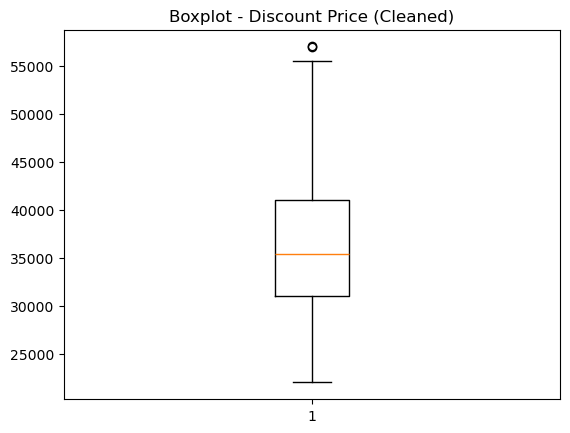

In [52]:
#  Boxplot After Removing Outliers
plt.figure()
plt.boxplot(data_clean["Discount Price"])
plt.title("Boxplot - Discount Price (Cleaned)")
plt.show()

In [53]:
## Skewness Calculation
numeric_cols = data_clean.select_dtypes(include=["int64", "float64"]).columns
skew_values = data_clean[numeric_cols].skew().sort_values(ascending=False)

print("Skewness of numeric columns:\n")
print(skew_values)

Skewness of numeric columns:

Ratings_Count     2.038910
Reviews_Count     1.613853
Discount Price    0.467281
Star Rating       0.410298
Original Price    0.076675
Rating            0.000000
Ton              -0.041257
dtype: float64


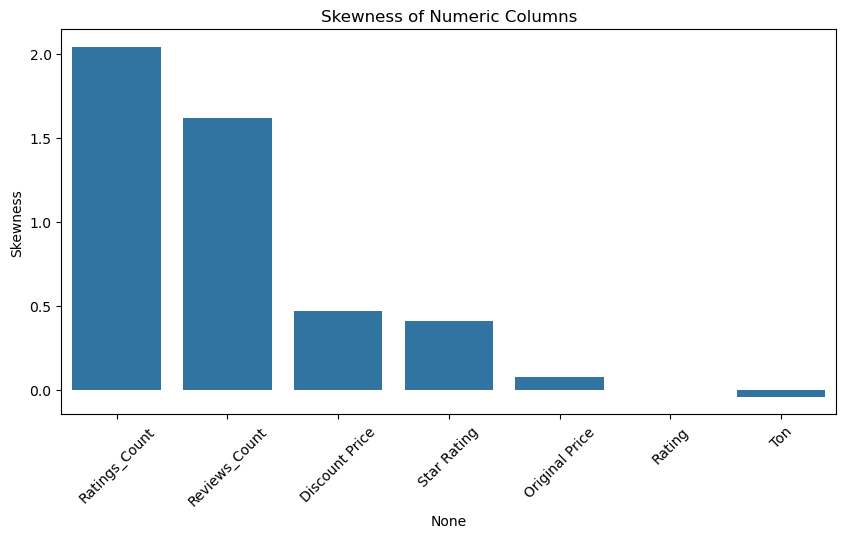

In [54]:
# Skewness of Numeric Columns
plt.figure(figsize=(10,5))
sns.barplot(x=skew_values.index, y=skew_values.values)
plt.xticks(rotation=45)
plt.ylabel("Skewness")
plt.title("Skewness of Numeric Columns")
plt.show()

In [55]:
# Dataset Summary Statistics
df.describe()

,Rating,Original Price,Discount Price,Ton,Star Rating,Ratings_Count,Reviews_Count
count,5.740000e+02,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000
mean,4.200000e+00,62259.873316,37436.505226,1.442056,3.756098,12998.083624,1308.883275
std,8.889531e-16,13111.793188,9095.871253,0.319422,0.984924,16241.901485,1549.293561
min,4.200000e+00,27600.000000,21990.000000,0.600000,2.000000,3.000000,0.000000
25%,4.200000e+00,53137.500000,31065.000000,1.400000,3.000000,1486.000000,147.000000
50%,4.200000e+00,62454.017699,35935.000000,1.500000,3.000000,6314.000000,700.000000
75%,4.200000e+00,70500.000000,41490.000000,1.500000,5.000000,20268.000000,2084.000000
max,4.200000e+00,125000.000000,87990.000000,3.000000,5.000000,77083.000000,6652.000000


In [56]:
# Count Non-Missing Values in Feature Column
df["Feature"].count()

np.int64(574)

In [58]:
# Count Unique Combinations of Multiple Columns
df[["Brand","Ton","Discount Price"]].value_counts()

Brand   Ton  Discount Price
Godrej  1.0  26999.0           5
Blue    1.5  40990.0           5
LG      1.5  41490.0           3
Voltas  1.5  30990.0           3
        2.0  42350.0           3
                              ..
realme  1.0  49999.0           1
        1.5  35499.0           1
             49699.0           1
             61699.0           1
        1.6  29490.0           1
Name: count, Length: 524, dtype: int64

In [59]:
# Find the Row with the Maximum Value in a Column
df.loc[df["Brand"].idxmax()]

Product Title          realme TechLife 2026 Model 1.6 Ton 3 Star Spli...
Rating                                                               4.2
Reviews                                            5 Ratings & 1 Reviews
Feature                Annual Power Usage: 684.9 UnitsRoom Size: 90 s...
Original Price                                                   53999.0
Discount percentage                                              45% off
Discount Price                                                   29490.0
Brand                                                             realme
Ton                                                                  1.6
Star Rating                                                          3.0
Ratings_Count                                                        5.0
Reviews_Count                                                        1.0
Name: 179, dtype: object

In [60]:
# Access Specific Columns for the Row with Maximum Value
df.loc[df["Brand"].idxmax(), ["Feature", "Brand","Ton"]]

Feature    Annual Power Usage: 684.9 UnitsRoom Size: 90 s...
Brand                                                 realme
Ton                                                      1.6
Name: 179, dtype: object

In [61]:
# View Top 10 Unique Brands After Sorting
df.sort_values("Brand")[["Brand","Ton","Discount Price"]].drop_duplicates().head(10)

,Brand,Ton,Discount Price
444,Acer,1.5,26985.0
744,Acer,1.0,25989.0
672,Acerpure,1.0,28490.0
508,BPL,1.5,27490.0
499,Blue,1.5,37603.0
792,Blue,1.5,39050.0
198,Blue,0.8,28490.0
209,Blue,1.5,39490.0
94,Blue,1.5,26990.0
862,Blue,1.5,39990.0


In [62]:
# View Top 10 Unique Products Sorted by Title
df.sort_values("Product Title")[["Product Title","Brand","Ton","Discount Price"]].drop_duplicates().head(10)

,Product Title,Brand,Ton,Discount Price
744,Acer 2025 Model 1 Ton 3 Star Split Inverter AC,Acer,1.0,25989.0
444,Acer 2025 Model 1.5 Ton 3 Star Split Inverter AC,Acer,1.5,26985.0
672,Acerpure 2025 Model 1 Ton 5 Star Split Inverte...,Acerpure,1.0,28490.0
508,BPL 2023 Model 1.5 Ton 3 Star Split Inverter w...,BPL,1.5,27490.0
968,Blue Star 2021 Model 1 Ton 5 Star Split Invert...,Blue,1.0,38650.0
419,Blue Star 2021 Model 1.5 Ton 3 Star Split AC,Blue,1.5,40651.0
159,Blue Star 2022 Model 1 Ton 2 Star Split Invert...,Blue,1.0,29999.0
162,Blue Star 2022 Model 1 Ton 3 Star Split Invert...,Blue,1.0,29490.0
288,Blue Star 2022 Model 1.5 Ton 5 Star Split Inve...,Blue,1.5,44850.0
809,Blue Star 2022 Model 1.5 Ton 5 Star Split Inve...,Blue,1.5,39850.0


In [63]:
# TOP PRODUCTS
top_products = df.sort_values(by=['Rating','Reviews'], ascending=False).head(10)

print("\nTop 10 Products:")
print(top_products[['Product Title','Rating','Reviews','Discount Price']])


Top 10 Products:
                                         Product Title  Rating  \
762  Hitachi 2022 Model 1 Ton 5 Star Split Inverter AC     4.2   
854  Hitachi 2024 Model 1 Ton 5 Star Split Inverter AC     4.2   
962  Hitachi 2023 Model 1 Ton 5 Star Split Inverter...     4.2   
103  Haier 2025 Model 2 Ton 3 Star Split Inverter I...     4.2   
573    Haier 2024 Model 2 Ton 3 Star Split Inverter AC     4.2   
682  Haier 2024 Model 2 Ton 3 Star Split Inverter w...     4.2   
735  Haier 2023 Model 2 Ton 3 Star Split Inverter F...     4.2   
399    CANDY 2023 Model 1 Ton 4 Star Split Inverter AC     4.2   
272  Samsung Bespoke AI 2026 Model 1 Ton 5 Star Spl...     4.2   
143  Blue Star 2023 Model 1.5 Ton 4 Star Split Inve...     4.2   

                       Reviews  Discount Price  
762  956 Ratings & 166 Reviews         41322.0  
854  956 Ratings & 166 Reviews         36999.0  
962  956 Ratings & 166 Reviews         38499.0  
103     94 Ratings & 8 Reviews         40990.0  
573     94

In [64]:
# View Top 5 Unique Products Sorted by Title in Descending Order
df.sort_values("Product Title",ascending = False )[["Product Title","Brand","Ton","Discount Price"]].drop_duplicates().head(5)

,Product Title,Brand,Ton,Discount Price
179,realme TechLife 2026 Model 1.6 Ton 3 Star Spli...,realme,1.6,29490.0
372,realme TechLife 2025 Model 1.5 Ton 5 Star Spli...,realme,1.5,61699.0
439,realme TechLife 2025 Model 1.5 Ton 3 Star Spli...,realme,1.5,49699.0
412,realme TechLife 2025 Model 1 Ton 3 Star Split ...,realme,1.0,47899.0
248,realme TechLife 2024 Model 1.5 Ton 5 Star Spli...,realme,1.5,35499.0


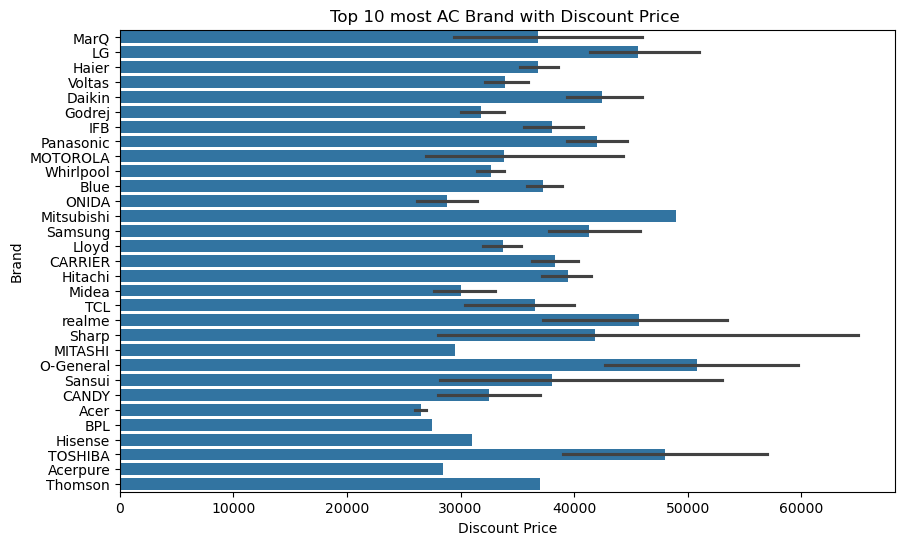

In [65]:
# using seaborn Bar Plot: Top 10 AC Brands by Discount Price
plt.figure(figsize=(10,6))
sns.barplot(data=df,
            y='Brand',
            x='Discount Price')
plt.title("Top 10 most AC Brand with Discount Price ")
plt.show()

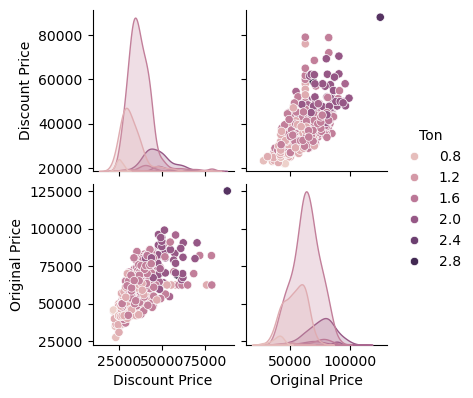

In [66]:
# using seaborn Pairplot of Price and AC Features
sns.pairplot(df[['Discount Price','Original Price','Brand', 'Ton']], hue = "Ton", height = 2)

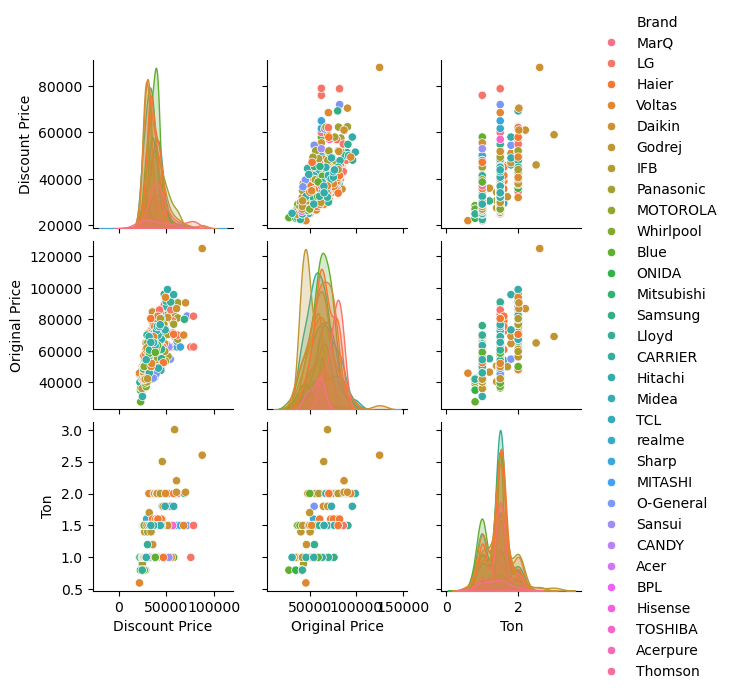

In [67]:
# using seaborn Pairplot of Price and AC Brand
sns.pairplot(df[['Discount Price','Original Price','Brand', 'Ton']], hue = 'Brand', height = 2)

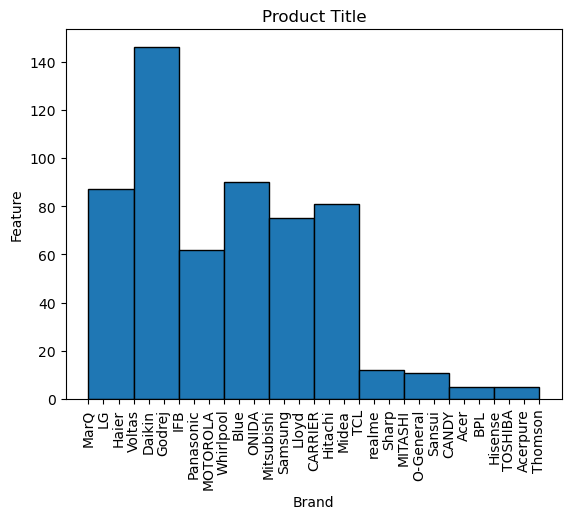

In [109]:
# Histogram plot using matplotlib
plt.hist(df["Brand"],bins = 10 ,edgecolor = "black")
plt.title("Product Title")
plt.xlabel("Brand")
plt.ylabel("Feature")
plt.xticks(rotation=90)
plt.show()

In [110]:
# SUMMARY STATISTICS
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
             Rating  Original Price  Discount Price         Ton  Star Rating  \
count  5.740000e+02      574.000000      574.000000  574.000000   574.000000   
mean   4.200000e+00    62259.873316    37436.505226    1.442056     3.756098   
std    8.889531e-16    13111.793188     9095.871253    0.319422     0.984924   
min    4.200000e+00    27600.000000    21990.000000    0.600000     2.000000   
25%    4.200000e+00    53137.500000    31065.000000    1.400000     3.000000   
50%    4.200000e+00    62454.017699    35935.000000    1.500000     3.000000   
75%    4.200000e+00    70500.000000    41490.000000    1.500000     5.000000   
max    4.200000e+00   125000.000000    87990.000000    3.000000     5.000000   

       Ratings_Count  Reviews_Count  
count     574.000000     574.000000  
mean    12998.083624    1308.883275  
std     16241.901485    1549.293561  
min         3.000000       0.000000  
25%      1486.000000     147.000000  
50%      6314.000000     700.

### UNIVARIATE ANALYSIS

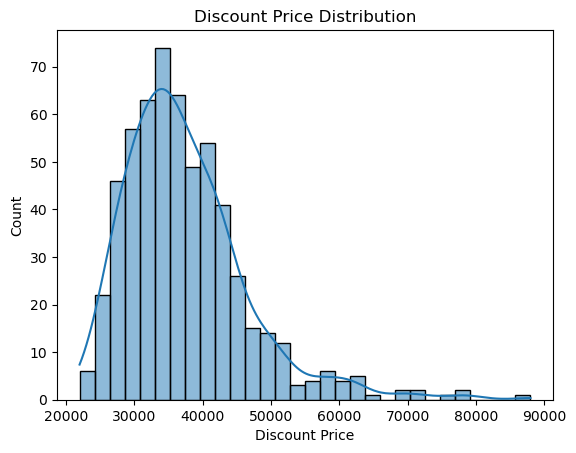

In [70]:
# Discount Price Distribution using seaborn
sns.histplot(df['Discount Price'], bins=30, kde=True)
plt.title("Discount Price Distribution")
plt.show()

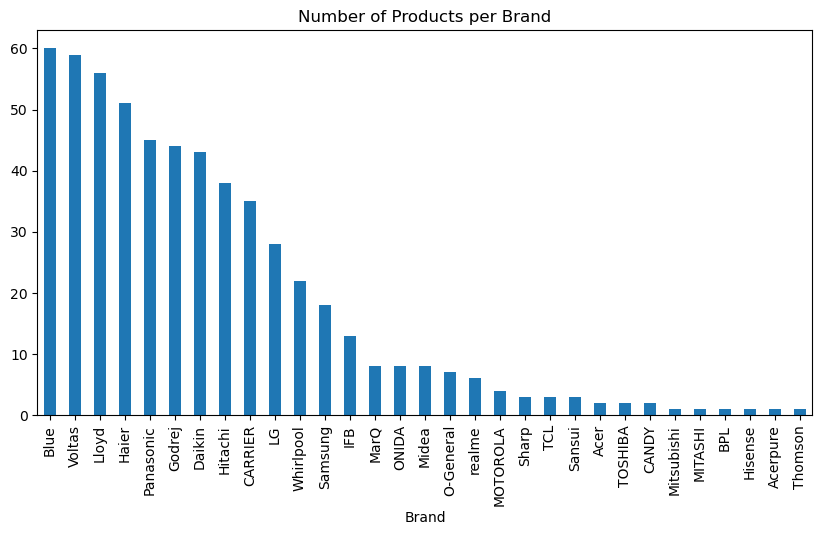

In [112]:
# Brand Distribution using Matplotlib
plt.figure(figsize=(10,5))
df["Brand"].value_counts().plot(kind="bar")
plt.title("Number of Products per Brand")
plt.xticks(rotation=90)
plt.show()

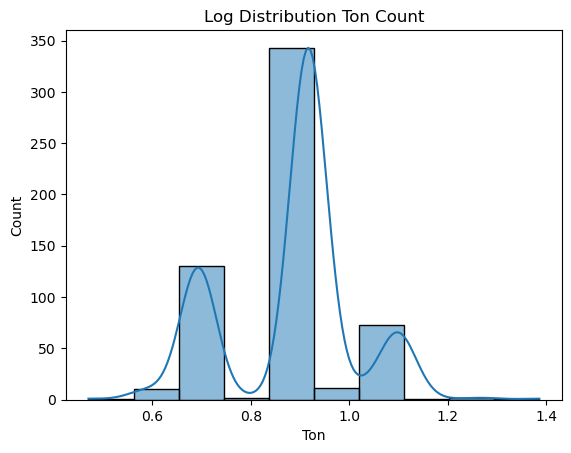

In [73]:
# Log distribution of Ratings Count (skew handling) using seaborn
sns.histplot(np.log1p(df['Ton']), bins=10, kde=True)
plt.title("Log Distribution Ton Count")
plt.show()

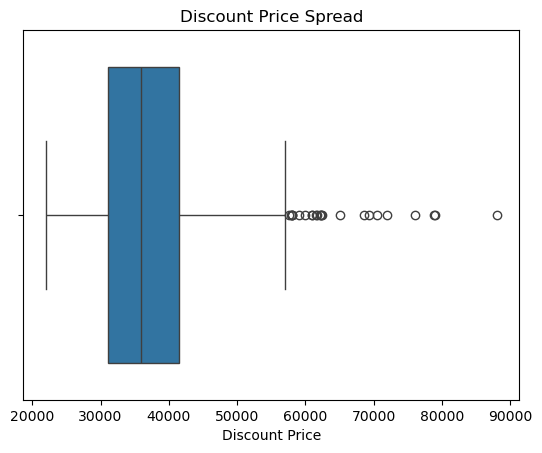

In [74]:
# Discount Price using seaborn
sns.boxplot(x=df['Discount Price'])
plt.title("Discount Price Spread")
plt.show()

### BIVARIATE ANALYSIS

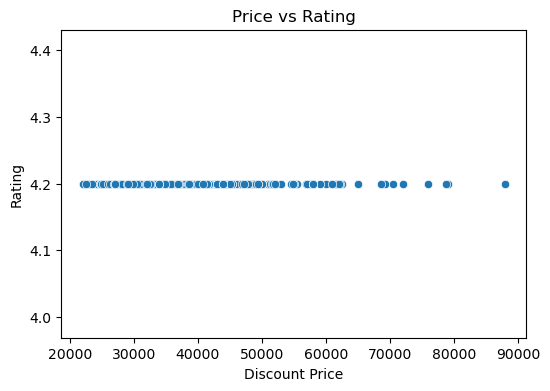

In [75]:
# Price vs Rating
plt.figure(figsize=(6,4))
sns.scatterplot(x="Discount Price", y="Rating", data=df)
plt.title("Price vs Rating")
plt.show()

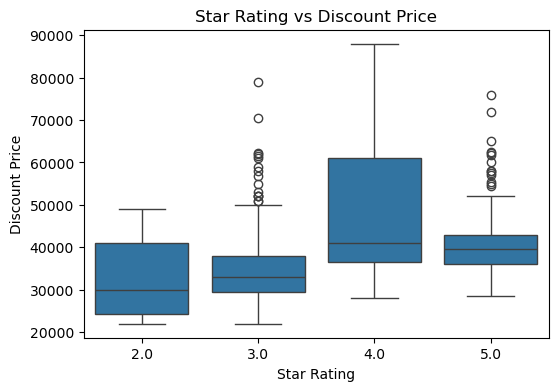

In [76]:
# Star Rating vs Price
plt.figure(figsize=(6,4))
sns.boxplot(x="Star Rating", y="Discount Price", data=df)
plt.title("Star Rating vs Discount Price")
plt.show()

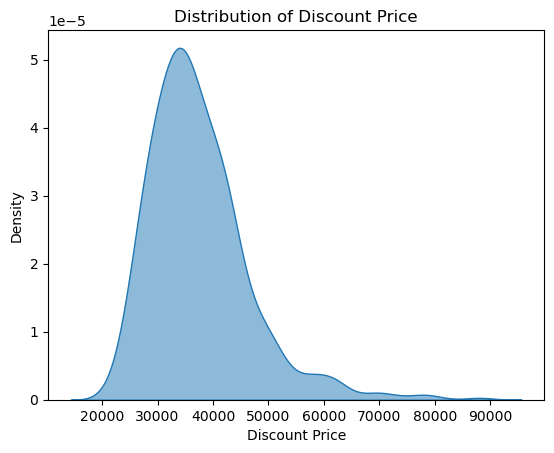

In [105]:
sns.kdeplot(df['Discount Price'], fill=True, alpha=0.5)
plt.title('Distribution of Discount Price')
plt.show()

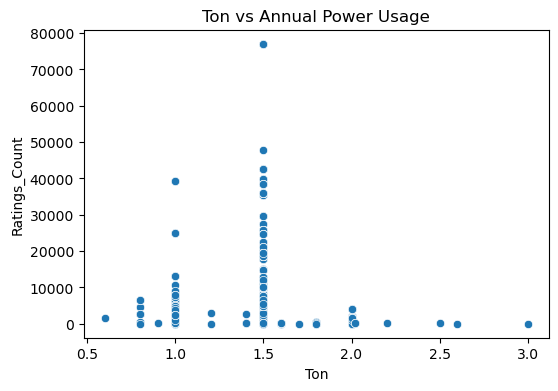

In [122]:
# Ton vs Annual Power Usage
plt.figure(figsize=(6,4))
sns.scatterplot(x="Ton", y="Ratings_Count", data=df)
plt.title("Ton vs Annual Power Usage")
plt.show()

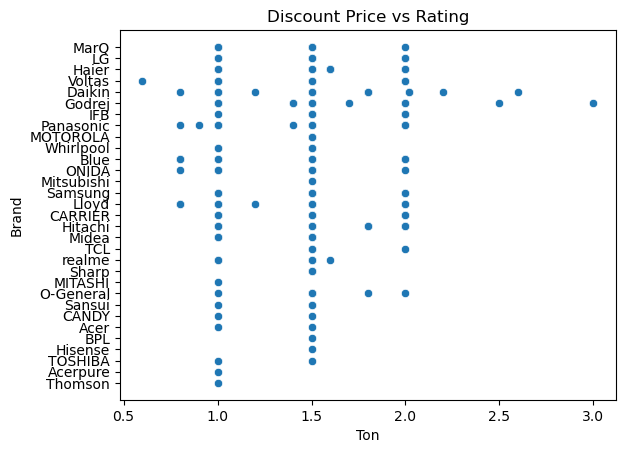

In [123]:
# Price vs Rating
sns.scatterplot(y='Brand', x='Ton', data=df)
plt.title("Discount Price vs Rating")
plt.show()


## Top 10 Most Reviewed ACs Product

In [126]:
top_reviewed = df.sort_values(by="Reviews", ascending=False).head(10)
top_reviewed[["Product Title", "Brand", "Reviews", "Rating", "Discount Price"]]

,Product Title,Brand,Reviews,Rating,Discount Price
962,Hitachi 2023 Model 1 Ton 5 Star Split Inverter...,Hitachi,956 Ratings & 166 Reviews,4.2,38499.0
854,Hitachi 2024 Model 1 Ton 5 Star Split Inverter AC,Hitachi,956 Ratings & 166 Reviews,4.2,36999.0
762,Hitachi 2022 Model 1 Ton 5 Star Split Inverter AC,Hitachi,956 Ratings & 166 Reviews,4.2,41322.0
735,Haier 2023 Model 2 Ton 3 Star Split Inverter F...,Haier,94 Ratings & 8 Reviews,4.2,45700.0
103,Haier 2025 Model 2 Ton 3 Star Split Inverter I...,Haier,94 Ratings & 8 Reviews,4.2,40990.0
682,Haier 2024 Model 2 Ton 3 Star Split Inverter w...,Haier,94 Ratings & 8 Reviews,4.2,44999.0
573,Haier 2024 Model 2 Ton 3 Star Split Inverter AC,Haier,94 Ratings & 8 Reviews,4.2,45264.0
399,CANDY 2023 Model 1 Ton 4 Star Split Inverter AC,CANDY,94 Ratings & 10 Reviews,4.2,27990.0
272,Samsung Bespoke AI 2026 Model 1 Ton 5 Star Spl...,Samsung,932 Ratings & 109 Reviews,4.2,37490.0
143,Blue Star 2023 Model 1.5 Ton 4 Star Split Inve...,Blue,928 Ratings & 100 Reviews,4.2,40990.0


### Brand-wise Analysis of ACs

In [137]:
brand_analysis = df.groupby("Brand").agg({
    "Rating": "mean",                               # Average rating per brand
    "Discount Price": "mean",                       # Average discount price per brand
    "Reviews": "sum"                                # Total reviews per brand
}).sort_values(by="Reviews", ascending=False)

brand_analysis.head(10)

,Rating,Discount Price,Reviews
Brand,,,
CANDY,4.2,32490.000000,94 Ratings & 10 Reviews109 Ratings & 11 Reviews
O-General,4.2,50774.428571,92 Ratings & 10 Reviews11 Ratings & 1 Reviews3...
ONIDA,4.2,28790.125000,"8,978 Ratings & 1,241 Reviews15,147 Ratings & ..."
Voltas,4.2,33934.474576,"77,083 Ratings & 6,652 Reviews77,083 Ratings &..."
Acerpure,4.2,28490.000000,7 Ratings & 0 Reviews
Acer,4.2,26487.000000,59 Ratings & 7 Reviews44 Ratings & 4 Reviews
Hitachi,4.2,39428.894737,"509 Ratings & 67 Reviews2,891 Ratings & 328 Re..."
realme,4.2,45714.166667,"5 Ratings & 1 Reviews1,157 Ratings & 116 Revie..."
TOSHIBA,4.2,47995.000000,5 Ratings & 0 Reviews3 Ratings & 2 Reviews


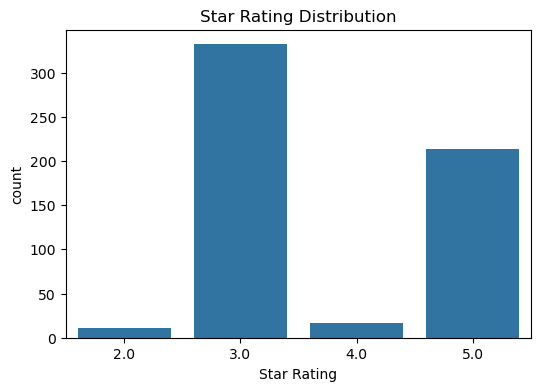

In [138]:
# Star Rating Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Star Rating", data=df)
plt.title("Star Rating Distribution")
plt.show()

In [155]:
# Average rating per brand
brand_summary = df.groupby('Brand')['Rating'].mean().sort_values(ascending=False)
top10 = brand_summary.head(10)
top10

Brand
Acer        4.2
Acerpure    4.2
BPL         4.2
Blue        4.2
CANDY       4.2
CARRIER     4.2
Daikin      4.2
Godrej      4.2
Haier       4.2
Hisense     4.2
Name: Rating, dtype: float64

In [157]:
df[['Ratings_Count','Reviews_Count']].head()

,Ratings_Count,Reviews_Count
0,39287.0,4917.0
1,42704.0,4066.0
3,1656.0,147.0
4,77083.0,6652.0
5,37.0,11.0


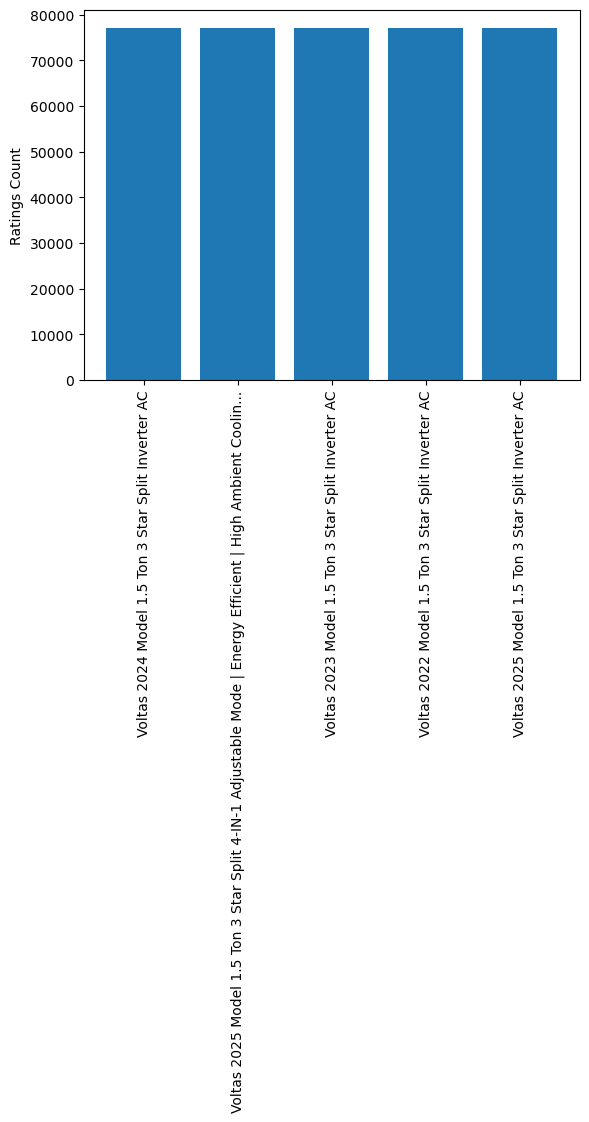

In [158]:
# Example: Top 10 products by number of ratings
top_rated = df.sort_values('Ratings_Count', ascending=False).head(10)
plt.bar(top_rated['Product Title'], top_rated['Ratings_Count'])
plt.xticks(rotation=90)
plt.ylabel('Ratings Count')
plt.show()

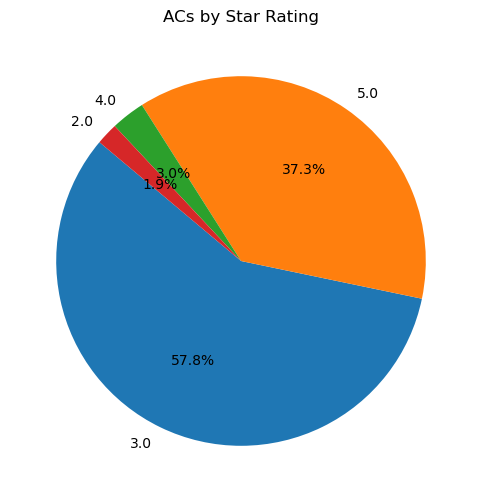

In [161]:
star_counts = df['Star Rating'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(star_counts, labels=star_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("ACs by Star Rating")
plt.show()

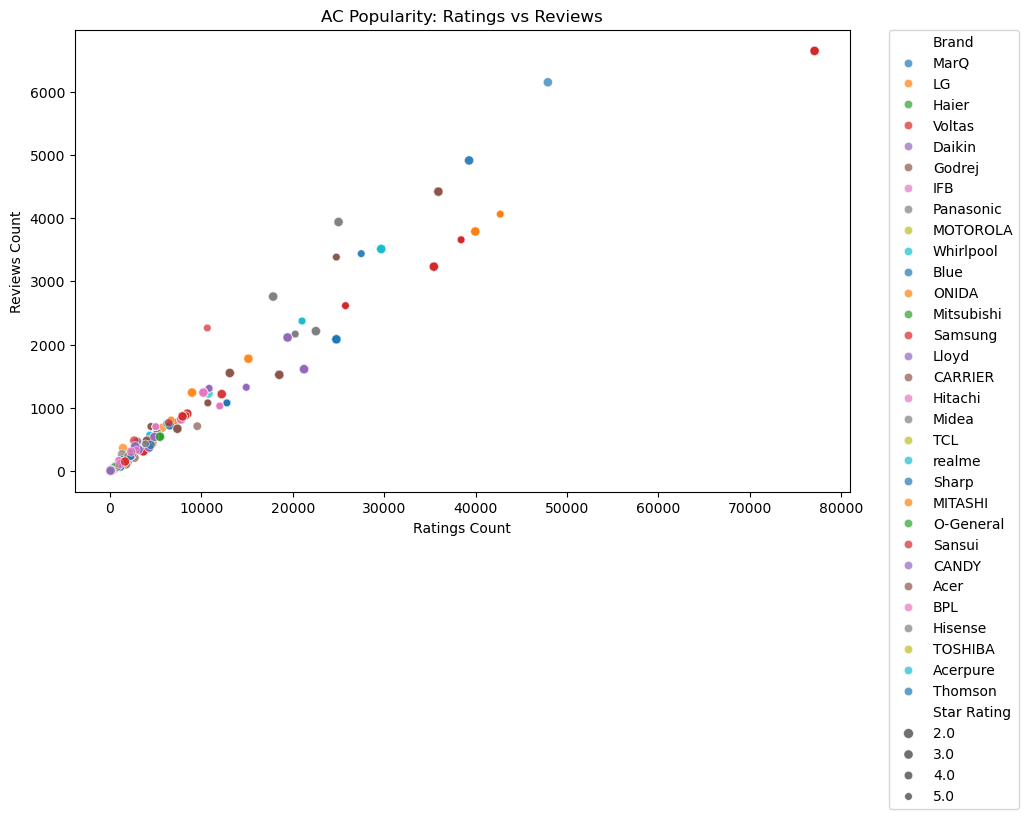

In [175]:
# --------------------------
# 6️⃣ Scatter Plot: Ratings Count vs Reviews Count
# --------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Ratings_Count', 
    y='Reviews_Count', 
    hue='Brand',       # Optional: color by Brand
    size='Star Rating',# Optional: size of marker by Star Rating
    sizes=(50, 30), 
    data=df, 
    palette='tab10', 
    alpha=0.7
)
plt.title("AC Popularity: Ratings vs Reviews")
plt.xlabel("Ratings Count")
plt.ylabel("Reviews Count")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

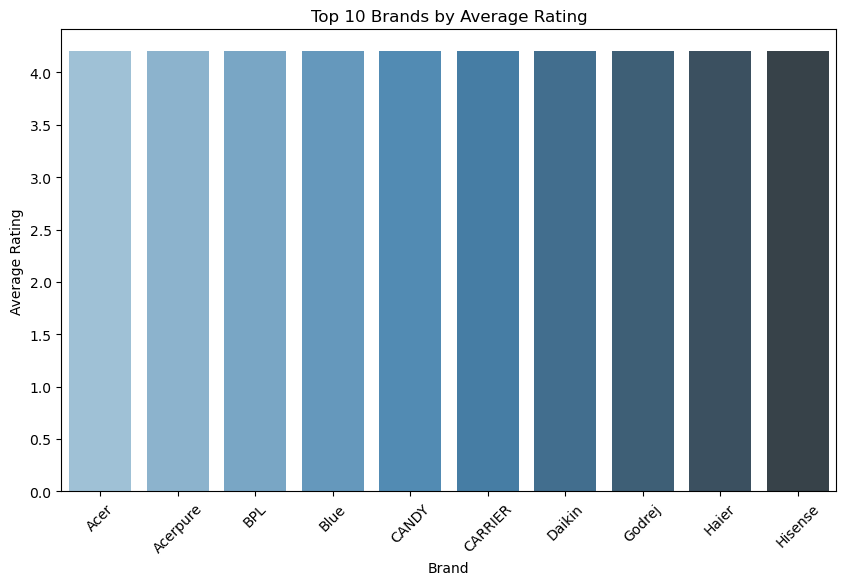

In [167]:
# --------------------------
# 1️⃣ Bar Chart: Top 10 Brands by Average Rating
# --------------------------
top_brands = df.groupby('Brand')['Rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_brands.index, y=top_brands.values, palette='Blues_d')
plt.title("Top 10 Brands by Average Rating")
plt.ylabel("Average Rating")
plt.xlabel("Brand")
plt.xticks(rotation=45)
plt.show()
